In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa

pd.options.future.infer_string = False
pd.options.mode.string_storage = "python"

# Demand year is 2015 as there is only data for 2015



def load_base_year_data(cf_year):
    """
    If cf_year = None then use 10 year average capacity factor data
    """
    demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)
    if cf_year is None:
        pass
    else:
        
        offshore_wind_cf_df = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv", index_col=0)
        onshore_wind_cf_df = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", index_col=0)
        pv_cf_df = pd.read_csv("../data/pv_capacity_factor_raw.csv", index_col=0)

        # Convert ISO8601 to datetime
        offshore_wind_cf_df["utc_time"] = pd.to_datetime(offshore_wind_cf["utc_time"], utc=True, errors="raise")
        onshore_wind_cf_df["utc_time"] = pd.to_datetime(onshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        pv_cf_df["utc_time"] = pd.to_datetime(pv_cf_df["utc_time"], utc=True, errors="raise")

        # Keep only time and Denmark
        df_pv = pv_cf_df[["utc_time", "DNK"]]
        df_onshore_wind = onshore_wind_cf_df[["utc_time", "DNK"]]
        df_offshore_wind = offshore_wind_cf_df[["utc_time", "DNK"]]

        # Rename columns
        df_pv = df_pv.rename(columns={"DNK": "pv_cf_dk"})
        df_onshore_wind = df_onshore_wind.rename(columns={"DNK": "onshore_cf_dk"})
        df_offshore_wind = df_offshore_wind.rename(columns={"DNK": "offshore_cf_dk"})
        
        # Remove year from capacity factor dataframes

    work_df = pd.concat([df_pv, df_onshore_wind, df_offshore_wind, demand], axis=1)
    work_df.index = pd.to_datetime(
        "2015/" + work_df.index.astype(str),
        format="%Y/%d/%m %H:%M"
    )
    work_df = work_df.rename(columns={"demand": "demand_mw"})
    return work_df


# Capacity factor year can be chosen to be different
capacity_factor_year = 2015

work_df = load_base_year_data(capacity_factor_year)
work_df.index = pd.DatetimeIndex(pd.to_datetime(work_df.index))
work_df.head()


,pv_cf,onshore_cf,offshore_cf,demand_mw
time,,,,
2015-01-01 00:00:00,0.0,0.419545,0.629273,3210.98
2015-01-01 01:00:00,0.0,0.407818,0.643364,3100.02
2015-01-01 02:00:00,0.0,0.396909,0.644636,2980.39
2015-01-01 03:00:00,0.0,0.395182,0.623364,2933.49
2015-01-01 04:00:00,0.0,0.386545,0.602273,2941.54


In [15]:
# Technology lifetimes
onshore_wind_lifetime = 30 # years
offshore_wind_lifetime = 30 # years
pv_lifetime = 35 # years
ccgt_lifetime = 25 # years
ocgt_lifetime = 25 # years
biomass_chp_lifetime = 25 # years

# CAPEX
onshore_wind_capex = 1160000 # EUR/MW
offshore_wind_capex = 2500000 # EUR/MW
pv_capex = 500000 # EUR/MW
ccgt_capex = 900000 # EUR/MW
ocgt_capex = 600000 # EUR/MW
biomass_chp_capex = 5000000 # EUR/MW

# Annualised capital costs
annualised_offshore_wind_capex = offshore_wind_capex / offshore_wind_lifetime # EUR/MW/year
annualised_onshore_wind_capex = onshore_wind_capex / onshore_wind_lifetime # EUR/MW/year
annualised_pv_capex = pv_capex / pv_lifetime # EUR/MW/year
annualised_ccgt_capex = ccgt_capex / ccgt_lifetime # EUR/MW/year
annualised_ocgt_capex = ocgt_capex / ocgt_lifetime # EUR/MW/year
annualised_chp_capex = biomass_chp_capex / biomass_chp_lifetime # EUR/MW/year

# Annual OPEX costs
offshore_wind_opex = 40000 # EUR/MW/year
onshore_wind_opex = 17000 # EUR/MW/year
pv_opex = 10500 # EUR/MW/year
ccgt_opex = 30500 # EUR/MW/year
ocgt_opex = 20000 # EUR/MW/year
chp_opex = 150000 # EUR/MW/year

# Efficiencies of generators
ccgt_efficiency = 0.57
ocgt_efficiency = 0.4
chp_efficiency = 0.25

# Input costs
gas_price = 30 # €/MWh
chp_input_price = 25 # €/MWh

# Setting up marginal generation costs
onshore_wind_marginal_cost = 4 # EUR/MWh
offshore_wind_marginal_cost = 2 # EUR/MWh
pv_marginal_cost = 0 # EUR/MWh
ccgt_marginal_cost = 4.5 + gas_price / ccgt_efficiency # EUR/MWh
ocgt_marginal_cost =  4.5 + gas_price / ocgt_efficiency # EUR/MWh
chp_marginal_cost = 15 + chp_input_price / chp_efficiency # EUR/MWh



# PyPsa setup


In [16]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)

n.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# Load
n.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["demand_mw"].to_numpy()
)

# --- Generators ---
n.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_max_pu = work_df["offshore_cf"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex),
)

n.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_max_pu = work_df["onshore_cf"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex),
)

n.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_max_pu = work_df["pv_cf"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex),
)

n.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom_extendable=True,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex),
)

n.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex),
)

n.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex),
)

In [17]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT
bus,DK,DK,DK,DK,DK,DK
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT
p_nom,0.0,0.0,0.0,0.0,0.0,0.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,83333.333333,38666.666667,14285.714286,200000.0,36000.0,24000.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5


In [18]:
# Solver
n.optimize(solver_name="highs")
#n.statistics()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 137.60it/s]
INFO:linopy.io: Writing time: 0.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 9.63e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

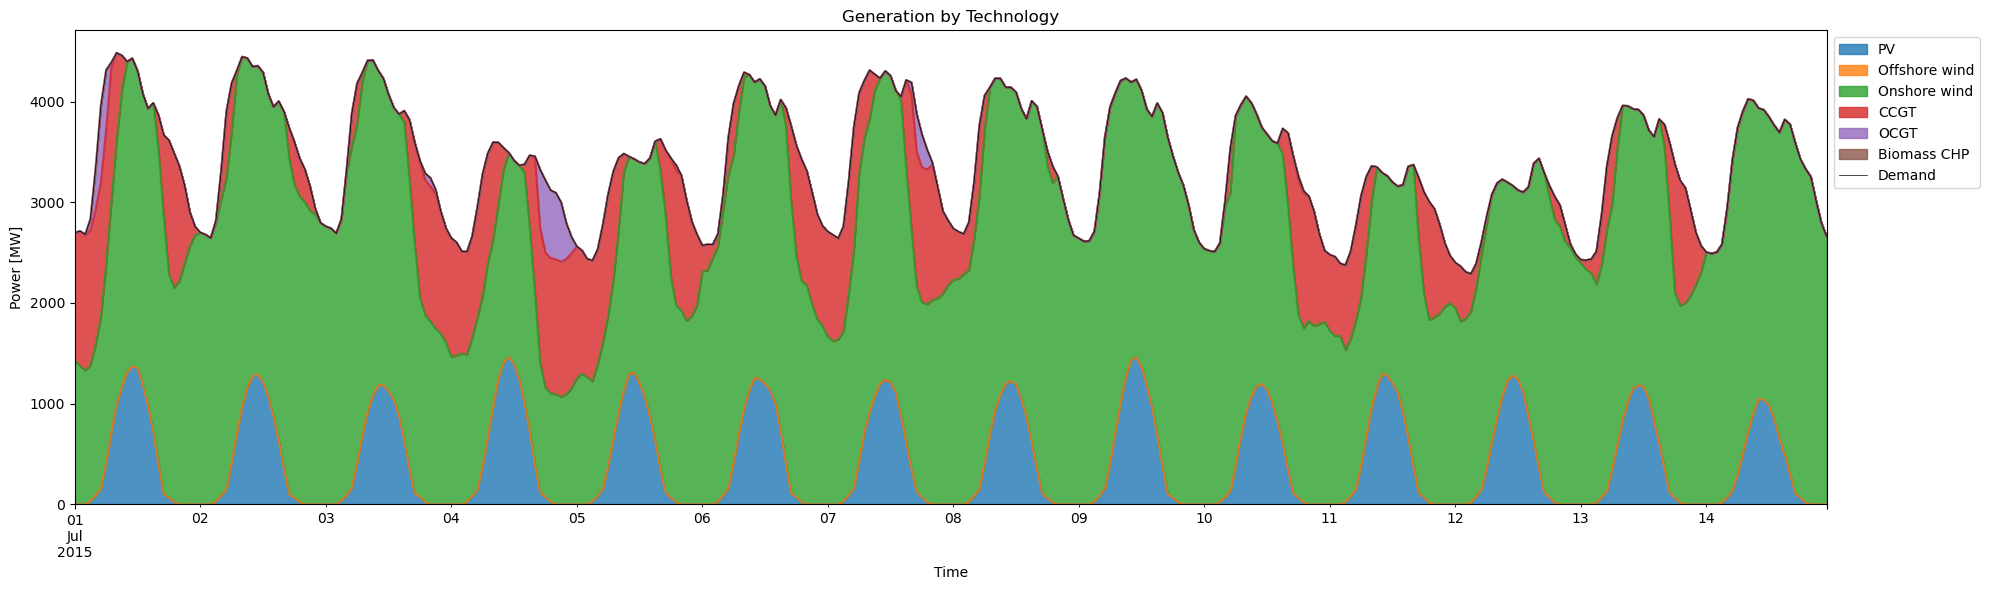

In [25]:
# Choose date range
start_date = "2015-07-01"
end_date   = "2015-07-14"

# --- Dispatch ---
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# --- Get marginal cost per technology ---
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)

# If multiple generators per tech → take mean (or min)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()

# Sort technologies (cheapest first)
tech_order = cost_by_tech.sort_values().index.tolist()

# Reorder columns
dispatch_nice = dispatch_nice[tech_order]

# --- Slice time ---
dispatch_plot = dispatch_nice.loc[start_date:end_date]
demand_plot = work_df.loc[start_date:end_date, "demand_mw"]

# --- Plot ---
ax = dispatch_plot.plot.area(figsize=(20, 6), alpha=0.8)

demand_plot.plot(
    ax=ax,
    linewidth=0.5,
    color="black",
    label="Demand"
)

plt.ylabel("Power [MW]")
plt.xlabel("Time")
plt.title("Generation by Technology")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [23]:
capacity = n.generators[["carrier", "p_nom_opt"]].copy()

# Map to nice names
capacity["Technology"] = capacity["carrier"].map(n.carriers.nice_name)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

print(capacity_table)

Technology
Onshore wind     14882.9
PV                2760.0
OCGT              1771.0
CCGT              1341.4
Biomass CHP          0.0
Offshore wind        0.0
Name: p_nom_opt, dtype: float64
